# Language Detection Module
This notebook builds the language detection component of the RAG-based e-commerce customer support chatbot.

The model uses the papluca/language-identification dataset, which contains 90,000 text samples across 20 languages.

Two traditional NLP approaches are compared:

1. Word level TF IDF + LinearSVC
2. Character level TF IDF + LinearSVC

The character level model is used as an enhancement because character patterns are highly useful for distinguishing languages.

In [1]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import joblib
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [3]:
dataset = load_dataset("papluca/language-identification")

dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

In [4]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (70000, 2)
Validation: (10000, 2)
Test: (10000, 2)


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [5]:
print(train_df.columns)
print()

print("Number of languages:", train_df["labels"].nunique())
print()

print(train_df["labels"].value_counts().sort_index())

Index(['labels', 'text'], dtype='str')

Number of languages: 20

labels
ar    3500
bg    3500
de    3500
el    3500
en    3500
es    3500
fr    3500
hi    3500
it    3500
ja    3500
nl    3500
pl    3500
pt    3500
ru    3500
sw    3500
th    3500
tr    3500
ur    3500
vi    3500
zh    3500
Name: count, dtype: int64


In [6]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(val_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Training missing values:
labels    0
text      0
dtype: int64

Validation missing values:
labels    0
text      0
dtype: int64

Test missing values:
labels    0
text      0
dtype: int64


In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text", "labels"]].head()

,text,clean_text,labels
0,"os chefes de defesa da estónia, letónia, lituâ...","os chefes de defesa da estónia, letónia, lituâ...",pt
1,размерът на хоризонталната мрежа може да бъде ...,размерът на хоризонталната мрежа може да бъде ...,bg
2,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...,zh
3,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของ...,th
4,Он увеличил давление .,Он увеличил давление .,ru


In [8]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True
)

X_train_word = word_vectorizer.fit_transform(train_df["clean_text"])
X_val_word = word_vectorizer.transform(val_df["clean_text"])

print("Training shape:", X_train_word.shape)
print("Validation shape:", X_val_word.shape)

Training shape: (70000, 50000)
Validation shape: (10000, 50000)


In [9]:
word_model = LinearSVC(
    C=1.0,
    random_state=42
)

word_model.fit(X_train_word, train_df["labels"])

word_val_predictions = word_model.predict(X_val_word)

word_accuracy = accuracy_score(
    val_df["labels"],
    word_val_predictions
)

print("Word TF-IDF Validation Accuracy:", word_accuracy)

Word TF-IDF Validation Accuracy: 0.9326


In [10]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5),
    min_df=2,
    max_features=120000,
    sublinear_tf=True
)

X_train_char = char_vectorizer.fit_transform(train_df["clean_text"])
X_val_char = char_vectorizer.transform(val_df["clean_text"])

print("Training shape:", X_train_char.shape)
print("Validation shape:", X_val_char.shape)

Training shape: (70000, 120000)
Validation shape: (10000, 120000)


In [11]:
char_model = LinearSVC(
    C=1.0,
    random_state=42
)

char_model.fit(X_train_char, train_df["labels"])

char_val_predictions = char_model.predict(X_val_char)

char_accuracy = accuracy_score(
    val_df["labels"],
    char_val_predictions
)

print("Character TF-IDF Validation Accuracy:", char_accuracy)

Character TF-IDF Validation Accuracy: 0.9954


In [12]:
results = pd.DataFrame({
    "Model": [
        "Word TF-IDF + LinearSVC",
        "Character TF-IDF + LinearSVC"
    ],
    "Validation Accuracy": [
        word_accuracy,
        char_accuracy
    ]
})

results

,Model,Validation Accuracy
0,Word TF-IDF + LinearSVC,0.9326
1,Character TF-IDF + LinearSVC,0.9954


In [13]:
X_test_char = char_vectorizer.transform(test_df["clean_text"])

test_predictions = char_model.predict(X_test_char)

test_accuracy = accuracy_score(
    test_df["labels"],
    test_predictions
)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.9953


In [14]:
print(
    classification_report(
        test_df["labels"],
        test_predictions,
        digits=4
    )
)

              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9980    1.0000    0.9990       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9960    1.0000    0.9980       500
          es     0.9980    0.9980    0.9980       500
          fr     0.9980    1.0000    0.9990       500
          hi     1.0000    0.9680    0.9837       500
          it     0.9940    0.9960    0.9950       500
          ja     1.0000    1.0000    1.0000       500
          nl     0.9960    0.9980    0.9970       500
          pl     1.0000    0.9940    0.9970       500
          pt     0.9940    0.9980    0.9960       500
          ru     1.0000    0.9980    0.9990       500
          sw     0.9432    0.9960    0.9689       500
          th     1.0000    0.9980    0.9990       500
          tr     0.9921    1.0000    0.9960       500
          ur     1.0000    

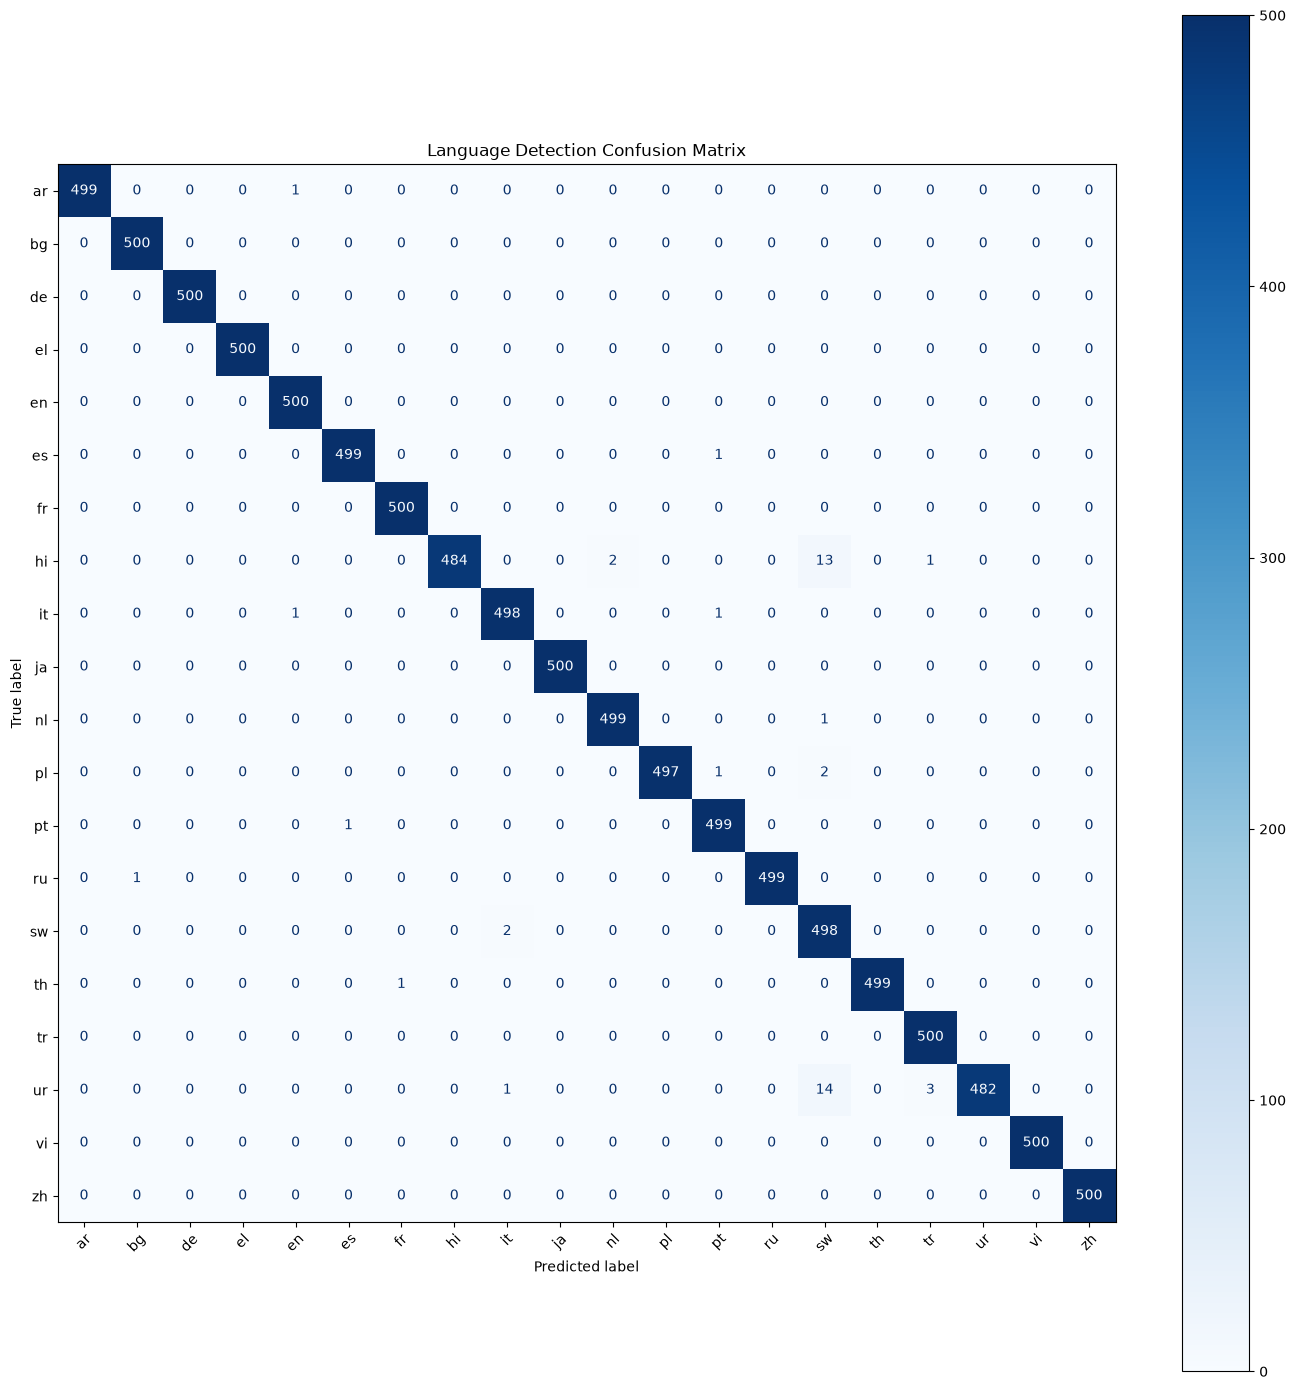

In [15]:
labels = sorted(test_df["labels"].unique())

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    test_df["labels"],
    test_predictions,
    labels=labels,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

plt.title("Language Detection Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
custom_messages = [
    "Where is my order?",
    "أين طلبي؟",
    "Où est ma commande ?",
    "¿Dónde está mi pedido?",
    "Wo ist meine Bestellung?",
    "Dove si trova il mio ordine?"
]

custom_vectors = char_vectorizer.transform(custom_messages)
custom_predictions = char_model.predict(custom_vectors)

for message, language in zip(custom_messages, custom_predictions):
    print(f"{message}  -->  {language}")

Where is my order?  -->  en
أين طلبي؟  -->  ar
Où est ma commande ?  -->  fr
¿Dónde está mi pedido?  -->  es
Wo ist meine Bestellung?  -->  de
Dove si trova il mio ordine?  -->  it


In [17]:
current_path = Path.cwd()

if current_path.name == "Jupyter notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Models directory:", models_dir)

Project root: e:\iti\ass10
Models directory: e:\iti\ass10\models


In [18]:
joblib.dump(
    char_model,
    models_dir / "language_model.pkl"
)

joblib.dump(
    char_vectorizer,
    models_dir / "language_vectorizer.pkl"
)

print("Language model saved successfully.")

Language model saved successfully.


In [19]:
loaded_model = joblib.load(
    models_dir / "language_model.pkl"
)

loaded_vectorizer = joblib.load(
    models_dir / "language_vectorizer.pkl"
)

test_message = ["I want to return my order"]

test_vector = loaded_vectorizer.transform(test_message)
prediction = loaded_model.predict(test_vector)[0]

print("Predicted language:", prediction)

Predicted language: en
